In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA


Load Dataset

In [6]:

df = pd.read_csv("../data/fitness.csv")

print("=== 5 Data Teratas ===")
display(df.head())

print("\n=== Informasi Dataset ===")
print(df.info())

print("\n=== Statistik Deskriptif ===")
display(df.describe())


=== 5 Data Teratas ===


,record_id,timestamp,user_id,age,gender,activity_type,duration_min,calories_burned,heart_rate_avg,steps,sleep_hours,weight_kg
0,1,2025-07-22 09:22:54,U026,67,Male,Cycling,7,322,175,3591,7.0,84.3
1,2,2025-05-28 13:53:54,U039,16,Female,Strength Training,83,265,113,22312,5.7,79.6
2,3,2025-08-07 01:36:54,U046,62,Female,Cycling,118,508,98,5418,6.6,88.3
3,4,2025-07-17 01:56:54,U048,56,Female,Swimming,75,270,150,19809,7.9,69.0
4,5,2025-08-11 03:22:54,U042,42,Other,Yoga,76,308,141,12562,5.0,61.6



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   record_id        200 non-null    int64  
 1   timestamp        200 non-null    object 
 2   user_id          200 non-null    object 
 3   age              200 non-null    int64  
 4   gender           200 non-null    object 
 5   activity_type    200 non-null    object 
 6   duration_min     200 non-null    int64  
 7   calories_burned  200 non-null    int64  
 8   heart_rate_avg   200 non-null    int64  
 9   steps            200 non-null    int64  
 10  sleep_hours      200 non-null    float64
 11  weight_kg        200 non-null    float64
dtypes: float64(2), int64(6), object(4)
memory usage: 18.9+ KB
None

=== Statistik Deskriptif ===


,record_id,age,duration_min,calories_burned,heart_rate_avg,steps,sleep_hours,weight_kg
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,100.500000,44.380000,64.025000,295.765000,120.935000,14020.82000,6.313000,70.152000
std,57.879185,15.417982,34.693987,120.563834,34.100366,6428.05981,1.911518,14.129562
min,1.000000,16.000000,5.000000,50.000000,60.000000,370.00000,3.000000,35.300000
25%,50.750000,33.000000,33.000000,220.000000,89.750000,9585.00000,4.775000,61.450000
50%,100.500000,43.000000,68.000000,311.500000,121.000000,14857.00000,6.500000,70.600000
75%,150.250000,58.000000,95.000000,378.000000,150.250000,19007.75000,7.900000,80.100000
max,200.000000,69.000000,119.000000,585.000000,179.000000,24984.00000,9.500000,105.200000


Pemrosesan Data

In [7]:
df['Calorie_Level'] = pd.cut(
    df['calories_burned'],
    bins=[0, 200, 400, float('inf')],
    labels=['Low', 'Medium', 'High']
)

print("\n=== Jumlah Data per Kategori ===")
print(df['Calorie_Level'].value_counts())

display(df[['calories_burned', 'Calorie_Level']].head(10))



=== Jumlah Data per Kategori ===
Calorie_Level
Medium    121
Low        41
High       38
Name: count, dtype: int64


,calories_burned,Calorie_Level
0,322,Medium
1,265,Medium
2,508,High
3,270,Medium
4,308,Medium
5,471,High
6,238,Medium
7,133,Low
8,500,High
9,210,Medium


In [9]:

target_col = 'Calorie_Level'

X = df.drop(columns=[target_col])
y = df[target_col]

for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [11]:
model = SVC(kernel='rbf', gamma='scale', C=1.0)

model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Akurasi: 0.825
              precision    recall  f1-score   support

        High       1.00      0.33      0.50         6
         Low       1.00      0.62      0.77         8
      Medium       0.79      1.00      0.88        26

    accuracy                           0.82        40
   macro avg       0.93      0.65      0.72        40
weighted avg       0.86      0.82      0.80        40



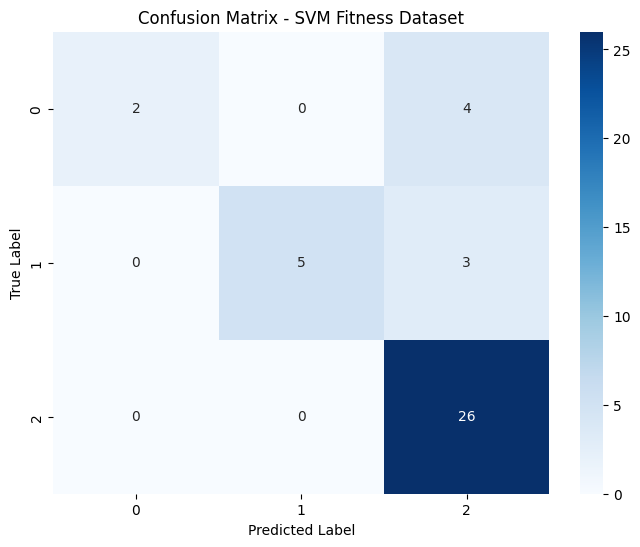

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM Fitness Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


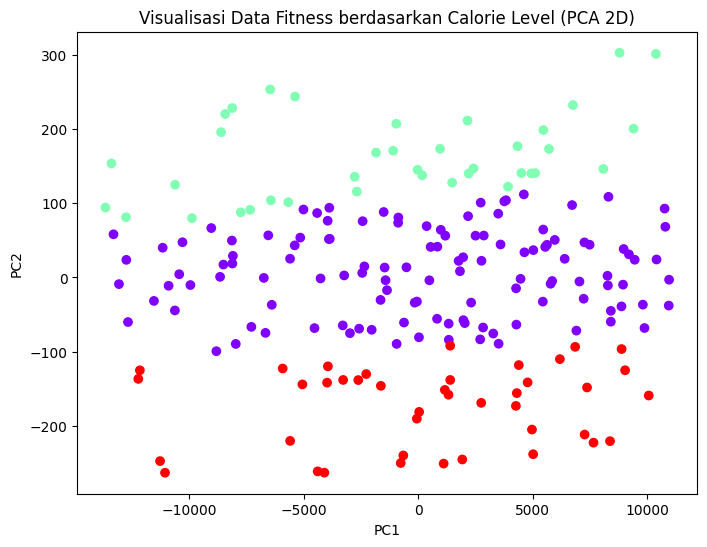

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=pd.factorize(y)[0], cmap='rainbow')
plt.title('Visualisasi Data Fitness berdasarkan Calorie Level (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


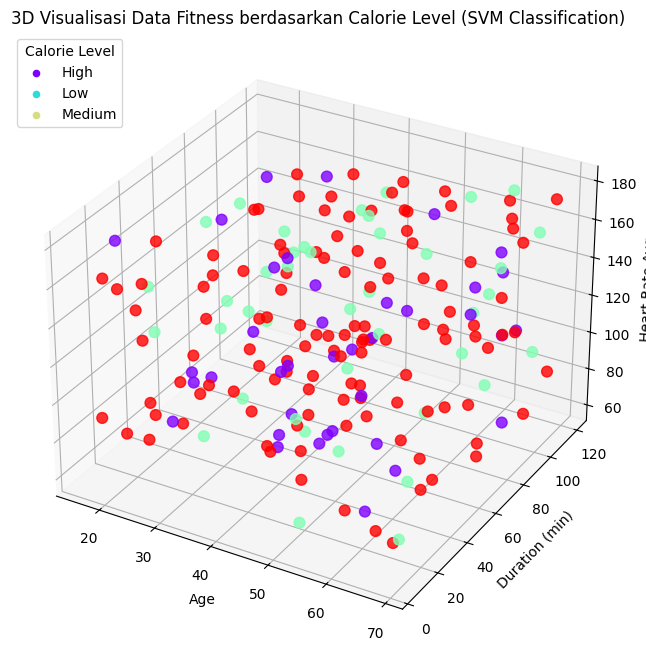

In [20]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

x1 = df['age']
x2 = df['duration_min']
x3 = df['heart_rate_avg']

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(x1, x2, x3, c=y_encoded, cmap='rainbow', s=60, alpha=0.8)

ax.set_xlabel('Age')
ax.set_ylabel('Duration (min)')
ax.set_zlabel('Heart Rate Avg')
ax.set_title('3D Visualisasi Data Fitness berdasarkan Calorie Level (SVM Classification)')

colors = [plt.cm.rainbow(i / len(encoder.classes_)) for i in range(len(encoder.classes_))]
for color, label in zip(colors, encoder.classes_):
    ax.scatter([], [], [], color=color, label=label)
    
ax.legend(title="Calorie Level", loc='upper left')

plt.show()
